<a href="https://colab.research.google.com/github/9c12manasvip-code/FAI-LAB-reg-no-29-/blob/main/fai_exp12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
EXPERIMENT 12

100%|██████████| 3.61M/3.61M [00:00<00:00, 30.0MB/s]

Extracting files...


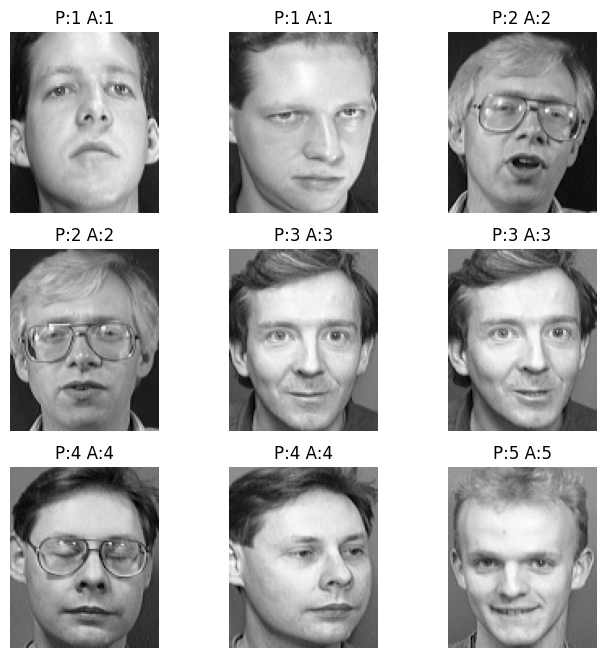

Accuracy: 0.9875


In [1]:
import os, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import kagglehub

path = kagglehub.dataset_download("kasikrit/att-database-of-faces")

def knn(X,y,t,k=3):
    d=np.sqrt(((X-t)**2).sum(1)); i=np.argsort(d)[:k]
    return Counter(y[i]).most_common(1)[0][0]

X,y=[],[]
for i in range(1,41):
    for j in range(1,11):
        img=np.array(Image.open(f"{path}/s{i}/{j}.pgm"))
        X.append(img.flatten()); y.append(i)

X,y=np.array(X),np.array(y)
Xtr,Xte,ytr,yte=[],[],[],[]
for i in range(40):
    Xtr+=list(X[i*10:i*10+8]); Xte+=list(X[i*10+8:i*10+10])
    ytr+=list(y[i*10:i*10+8]); yte+=list(y[i*10+8:i*10+10])

Xtr,Xte,ytr,yte=map(np.array,[Xtr,Xte,ytr,yte])
pred=[knn(Xtr,ytr,x) for x in Xte]

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(Xte[i].reshape(112,92), cmap="gray")
    plt.title(f"P:{pred[i]} A:{yte[i]}")
    plt.axis("off")
plt.show()

print("Accuracy:", np.mean(pred==yte))

In [2]:
import os

# The 'path' variable should still hold the dataset path from the previous execution
print(f"Listing contents of: {path}")

# List contents of the downloaded directory to understand its structure
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')
    if level == 1: # Limit depth to avoid too much output, show immediate subdirectories and files
        break

Listing contents of: /root/.cache/kagglehub/datasets/kasikrit/att-database-of-faces/versions/2
2/
    README
    s32/
        4.pgm
        3.pgm
        9.pgm
        1.pgm
        7.pgm
        10.pgm
        5.pgm
        2.pgm
        6.pgm
        8.pgm


Please run the above cell. Once we see the actual structure of the downloaded dataset, I can help you adjust the img_path in the original code to correctly load the images.